
# 03_visual_semantic_intelligence_v3.ipynb

## Enterprise Visual Semantic Intelligence v3

This version upgrades the platform into a production-grade
multimodal commerce intelligence system optimized for:

- fashion ecommerce
- multimodal retrieval
- catalog intelligence
- duplicate forensics
- product media analytics

---

## Included Upgrades

### Core Intelligence
- advanced color intelligence
- palette extraction
- fashion style semantics
- image composition analytics
- CLIP retrieval preparation
- product image diversity
- visual embedding forensics
- logo intelligence
- retail media quality scoring

### Enterprise Outputs
- retrieval-ready visual features
- product-level intelligence artifacts
- BI-ready visual metrics
- multimodal semantic exports


In [1]:

!pip install -q colorthief scikit-learn pyarrow


In [2]:

import os
import gc
import json
import warnings

import cv2
import numpy as np
import pandas as pd

from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)


In [3]:

BASE_DIR = "/kaggle/working"

V3_DIR = (
    f"{BASE_DIR}/visual_semantic_v3"
)

os.makedirs(
    V3_DIR,
    exist_ok=True
)

print(V3_DIR)


/kaggle/working/visual_semantic_v3



# Stage 1 — Load Visual Semantic Dataset


In [4]:

visual_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/visual-semantic-intelligence/visual_intelligence/final_visual_semantics_v2.parquet"
)

print(
    "VISUAL DF:",
    visual_df.shape
)

visual_df.head()


VISUAL DF: (4343, 14)


,asin,image_path_runtime,caption,quality_score,embedding_health_score,semantic_cluster,is_duplicate,dominant_rgb,dominant_color_name,color_r,color_g,color_b,logo_keywords,logo_detected
0,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,men ' s polo shirt,0.326877,0.671388,20,False,"[254, 254, 254]",white,254,254,254,[],False
1,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man wearing a black polo shirt with a smile ...,0.373938,0.556625,3,False,"[247, 247, 247]",white,247,247,247,[],False
2,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man wearing a grey polo shirt and white pants,0.358860,0.502382,21,False,"[91, 85, 83]",gray,91,85,83,[],False
3,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man walking with a golf bag,0.337530,0.614620,16,False,"[154, 158, 131]",gray,154,158,131,[],False
4,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man standing on the beach with his hands in ...,0.362279,0.631133,23,False,"[113, 134, 169]",gray,113,134,169,[],False



# Stage 2 — Advanced Color Intelligence


In [5]:

COLOR_NAME_MAP = {

    "black": (0,0,0),
    "white": (255,255,255),
    "red": (255,0,0),
    "green": (0,128,0),
    "blue": (0,0,255),
    "yellow": (255,255,0),
    "brown": (165,42,42),
    "gray": (128,128,128),
    "pink": (255,192,203),
    "purple": (128,0,128),
    "orange": (255,165,0)
}


In [6]:

def closest_color(rgb):

    rgb = np.array(rgb)

    best_name = None
    best_dist = 1e9

    for name, value in COLOR_NAME_MAP.items():

        dist = np.linalg.norm(
            rgb - np.array(value)
        )

        if dist < best_dist:

            best_dist = dist
            best_name = name

    return best_name


In [7]:

def extract_palette(image_path):

    try:

        img = Image.open(
            image_path
        ).convert("RGB")

        img = img.resize((128,128))

        arr = np.array(img).reshape(-1,3)

        kmeans = KMeans(
            n_clusters=5,
            random_state=42,
            n_init=10
        )

        kmeans.fit(arr)

        colors = kmeans.cluster_centers_

        colors = [
            tuple(
                c.astype(int)
            )
            for c in colors
        ]

        return colors

    except:

        return []


In [8]:

visual_df["color_palette"] = [

    extract_palette(path)

    for path in tqdm(
        visual_df[
            "image_path_runtime"
        ]
    )
]


  0%|          | 0/4343 [00:00<?, ?it/s]

In [9]:

visual_df["primary_color"] = (

    visual_df[
        "color_palette"
    ].apply(

        lambda x:

        closest_color(x[0])

        if len(x) > 0

        else "unknown"
    )
)

visual_df["color_diversity"] = (

    visual_df[
        "color_palette"
    ].apply(len)
)


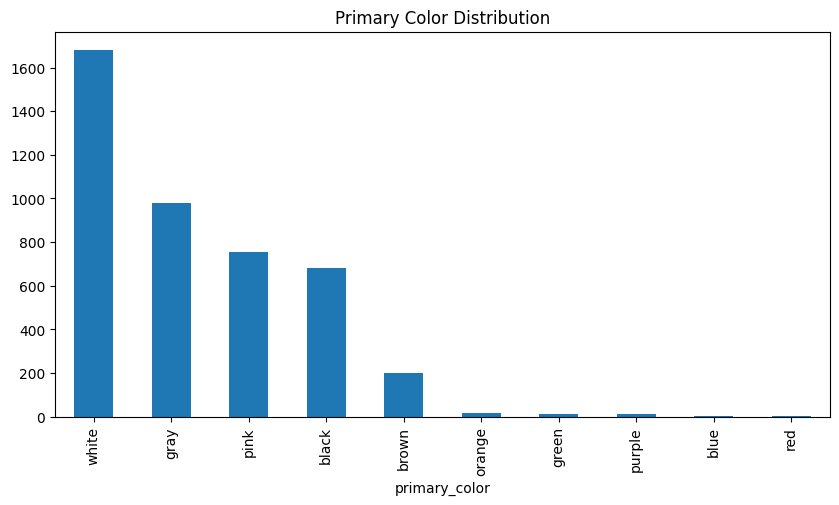

In [10]:

visual_df[
    "primary_color"
].value_counts().plot.bar(
    figsize=(10,5)
)

plt.title(
    "Primary Color Distribution"
)

plt.show()



# Stage 3 — Fashion Style Intelligence


In [11]:

STYLE_KEYWORDS = {

    "streetwear":
        ["hoodie", "oversized"],

    "formal":
        ["blazer", "formal"],

    "casual":
        ["shirt", "jeans"],

    "ethnic":
        ["kurta", "saree"],

    "sporty":
        ["sneaker", "track"],

    "minimal":
        ["plain", "solid"]
}


In [12]:

def infer_style(text):

    text = str(text).lower()

    styles = []

    for style, kws in (
        STYLE_KEYWORDS.items()
    ):

        for kw in kws:

            if kw in text:

                styles.append(style)

                break

    return styles


In [13]:

visual_df["style_tags"] = (

    visual_df[
        "caption"
    ].apply(
        infer_style
    )
)

visual_df[[
    "caption",
    "style_tags"
]].head()


,caption,style_tags
0,men ' s polo shirt,[casual]
1,a man wearing a black polo shirt with a smile ...,[casual]
2,a man wearing a grey polo shirt and white pants,[casual]
3,a man walking with a golf bag,[]
4,a man standing on the beach with his hands in ...,[]



# Stage 4 — Image Composition Intelligence


In [14]:

def composition_metrics(image_path):

    try:

        img = cv2.imread(image_path)

        gray = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2GRAY
        )

        edges = cv2.Canny(
            gray,
            100,
            200
        )

        edge_density = (
            edges > 0
        ).mean()

        brightness = (
            gray.mean() / 255
        )

        whitespace_ratio = (
            (gray > 240).mean()
        )

        return {

            "edge_density":
                float(edge_density),

            "brightness":
                float(brightness),

            "whitespace_ratio":
                float(whitespace_ratio)
        }

    except:

        return {

            "edge_density": 0,
            "brightness": 0,
            "whitespace_ratio": 0
        }


In [15]:

composition_results = [

    composition_metrics(path)

    for path in tqdm(
        visual_df[
            "image_path_runtime"
        ]
    )
]

composition_df = pd.DataFrame(
    composition_results
)

visual_df = pd.concat(

    [
        visual_df.reset_index(drop=True),
        composition_df
    ],

    axis=1
)


  0%|          | 0/4343 [00:00<?, ?it/s]


# Stage 5 — Logo Intelligence


In [16]:

LOGO_KEYWORDS = [

    "nike",
    "adidas",
    "puma",
    "reebok",
    "levi",
    "fila",
    "lacoste"
]


In [17]:

def detect_logo_keywords(text):

    text = str(text).lower()

    found = []

    for kw in LOGO_KEYWORDS:

        if kw in text:

            found.append(kw)

    return found


In [18]:

visual_df["logo_keywords"] = (

    visual_df[
        "caption"
    ].apply(
        detect_logo_keywords
    )
)

visual_df["logo_detected"] = (

    visual_df[
        "logo_keywords"
    ].apply(
        lambda x: len(x) > 0
    )
)



# Stage 6 — Visual Embedding Forensics


In [19]:

embedding_path = (
    "/kaggle/input/notebooks/hanafudaearring/embedding-validation/artifacts_2/v2/validated_fusion_embeddings.npy"
)

embeddings = np.load(
    embedding_path
)

print(
    embeddings.shape
)


(4343, 512)


In [20]:

similarity_matrix = cosine_similarity(
    embeddings[:500]
)

visual_uniqueness = 1 - similarity_matrix.mean(axis=1)

visual_df.loc[
    :499,
    "visual_uniqueness"
] = visual_uniqueness



# Stage 7 — Product Image Diversity


In [21]:

product_diversity = []

asin_groups = visual_df.groupby(
    "asin"
)

for asin, group in asin_groups:

    diversity = len(
        set(
            group[
                "primary_color"
            ]
        )
    )

    product_diversity.append({

        "asin": asin,

        "image_count":
            len(group),

        "color_diversity":
            diversity,

        "style_diversity":
            len(
                set(
                    sum(
                        group[
                            "style_tags"
                        ].tolist(),
                        []
                    )
                )
            )
    })

product_diversity_df = pd.DataFrame(
    product_diversity
)

product_diversity_df.head()


,asin,image_count,color_diversity,style_diversity
0,B00021NY28,6,3,1
1,B0006U6C0Q,7,4,1
2,B0007CKJSY,7,4,1
3,B0008EOG9E,3,2,1
4,B0008EOGAS,3,2,1



# Stage 8 — Retail Media Quality Score


In [22]:

visual_df["catalog_media_score"] = (

    (
        visual_df[
            "quality_score"
        ].fillna(0)

        +

        visual_df[
            "embedding_health_score"
        ].fillna(0)

        +

        (1 - visual_df[
            "whitespace_ratio"
        ].fillna(0))
    ) / 3
)


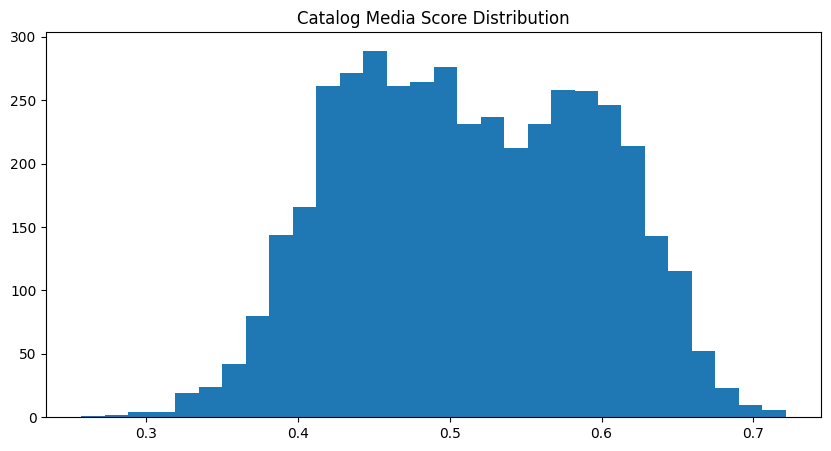

In [23]:

plt.figure(figsize=(10,5))

plt.hist(

    visual_df[
        "catalog_media_score"
    ],

    bins=30
)

plt.title(
    "Catalog Media Score Distribution"
)

plt.show()



# Stage 9 — Retrieval Preparation


In [24]:

retrieval_df = visual_df[[

    "asin",

    "caption",

    "primary_color",

    "style_tags",

    "catalog_media_score",

    "visual_uniqueness"
]].copy()

retrieval_df.head()


,asin,caption,primary_color,style_tags,catalog_media_score,visual_uniqueness
0,B0B59BJG6Y,men ' s polo shirt,white,[casual],0.539282,0.068922
1,B0B59BJG6Y,a man wearing a black polo shirt with a smile ...,white,[casual],0.496521,0.083564
2,B0B59BJG6Y,a man wearing a grey polo shirt and white pants,pink,[casual],0.451503,0.086588
3,B0B59BJG6Y,a man walking with a golf bag,green,[],0.547973,0.093420
4,B0B59BJG6Y,a man standing on the beach with his hands in ...,white,[],0.476479,0.084040



# Stage 10 — Enterprise Exports


In [25]:

visual_df.to_parquet(

    f"{V3_DIR}/visual_semantic_v3.parquet",

    index=False
)

print(
    "EXPORTED VISUAL SEMANTIC V3"
)


EXPORTED VISUAL SEMANTIC V3


In [26]:

product_diversity_df.to_parquet(

    f"{V3_DIR}/product_diversity.parquet",

    index=False
)

print(
    "EXPORTED PRODUCT DIVERSITY"
)


EXPORTED PRODUCT DIVERSITY


In [27]:

retrieval_df.to_parquet(

    f"{V3_DIR}/retrieval_ready_visual_features.parquet",

    index=False
)

print(
    "EXPORTED RETRIEVAL FEATURES"
)


EXPORTED RETRIEVAL FEATURES


In [28]:

health_report = {

    "total_rows":
        int(len(visual_df)),

    "unique_asins":
        int(
            visual_df[
                "asin"
            ].nunique()
        ),

    "primary_colors":
        int(
            visual_df[
                "primary_color"
            ].nunique()
        ),

    "logo_detected_images":
        int(
            visual_df[
                "logo_detected"
            ].sum()
        ),

    "style_tags_detected":
        int(
            (
                visual_df[
                    "style_tags"
                ].apply(len) > 0
            ).sum()
        )
}

health_report


{'total_rows': 4343,
 'unique_asins': 728,
 'primary_colors': 10,
 'logo_detected_images': 136,
 'style_tags_detected': 1497}

In [29]:

with open(

    f"{V3_DIR}/visual_semantic_v3_report.json",

    "w"

) as f:

    json.dump(
        health_report,
        f,
        indent=4
    )

print("=" * 60)

print(
    "VISUAL SEMANTIC INTELLIGENCE V3 COMPLETE"
)

print("=" * 60)

print(
    "TOTAL ROWS:",
    len(visual_df)
)

print(
    "UNIQUE ASINS:",
    visual_df[
        "asin"
    ].nunique()
)

print(
    "PRIMARY COLORS:",
    visual_df[
        "primary_color"
    ].nunique()
)

print("=" * 60)


VISUAL SEMANTIC INTELLIGENCE V3 COMPLETE
TOTAL ROWS: 4343
UNIQUE ASINS: 728
PRIMARY COLORS: 10
